# 05 — Parser Comparison

Comparação entre Regex Parser e LLM Parser (Gemini 3.5 Flash).

Baseado nos resultados do Exp 9 e Exp 10 (já executados via `run_experiments.py`).

Métricas:
- F1 Score (field-level)
- ANLS (Average Normalized Levenshtein Similarity)
- Zero-shot vs Few-shot
- Latência e custo

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RESULTS_DIR = Path('../results')

with open(RESULTS_DIR / 'metrics' / 'experiments.json') as f:
    experiments = json.load(f)

exp9 = experiments['exp9']
exp10 = experiments['exp10']
print('Exp 9 keys:', list(exp9.keys()))
print('Exp 10 keys:', list(exp10.keys()))

Exp 9 keys: ['Regex', 'LLM (Gemini)']
Exp 10 keys: ['Zero-shot', 'Few-shot']


## 1. Regex vs LLM — F1 e ANLS

In [2]:
# Exp 9 results
parsers = list(exp9.keys())
f1_means = [exp9[p]['f1_mean'] for p in parsers]
anls_means = [exp9[p]['anls_mean'] for p in parsers]
total_em = [exp9[p]['total_em'] for p in parsers]
latencies = [exp9[p]['avg_time_ms'] for p in parsers]

print(f"{'Parser':<16} {'F1':>6} {'ANLS':>6} {'Total EM':>9} {'Latency':>10}")
print('-' * 52)
for p, f1, anls, em, lat in zip(parsers, f1_means, anls_means, total_em, latencies):
    print(f"{p:<16} {f1:>6.3f} {anls:>6.3f} {em:>8.1%} {lat:>8.1f}ms")

Parser               F1   ANLS  Total EM    Latency
----------------------------------------------------
Regex             0.554  0.517    60.0%      4.2ms
LLM (Gemini)      0.681  0.747    70.0%   4286.1ms


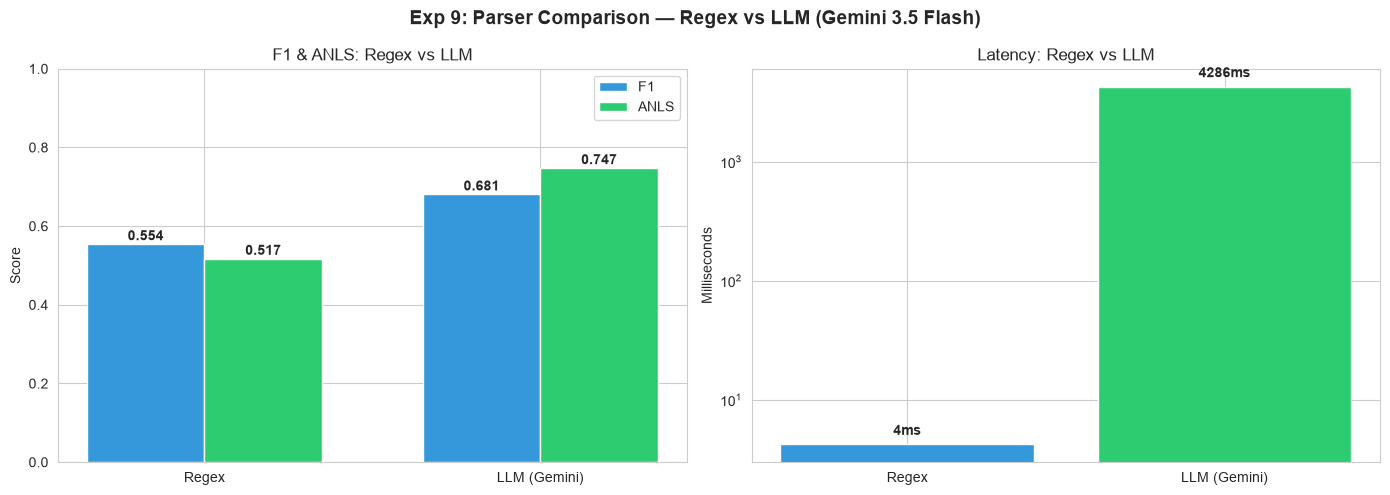

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#2ecc71']
x = np.arange(len(parsers))
width = 0.35

# F1 and ANLS
bars1 = ax1.bar(x - width/2, f1_means, width, label='F1', color=colors[0])
bars2 = ax1.bar(x + width/2, anls_means, width, label='ANLS', color=colors[1])
ax1.set_xticks(x)
ax1.set_xticklabels(parsers)
ax1.set_ylabel('Score')
ax1.set_title('F1 & ANLS: Regex vs LLM')
ax1.set_ylim(0, 1)
ax1.legend()
for bar in bars1 + bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Latency (log scale)
ax2.bar(parsers, latencies, color=colors)
ax2.set_ylabel('Milliseconds')
ax2.set_title('Latency: Regex vs LLM')
ax2.set_yscale('log')
for i, lat in enumerate(latencies):
    ax2.text(i, lat * 1.2, f'{lat:.0f}ms', ha='center', fontweight='bold')

plt.suptitle('Exp 9: Parser Comparison — Regex vs LLM (Gemini 3.5 Flash)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'parser_comparison_detailed.png', bbox_inches='tight')
plt.show()

## 2. Trade-off: Quality vs Cost

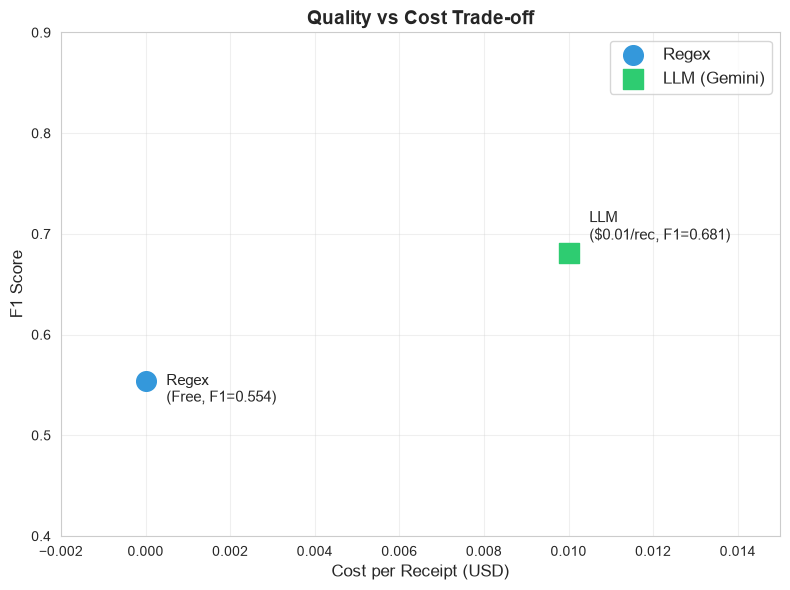

In [4]:
# Cost estimation
cost_per_receipt_regex = 0  # Free
cost_per_receipt_llm = 0.01  # ~$0.01 per receipt (Gemini 3.5 Flash)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(cost_per_receipt_regex, f1_means[0], s=200, c='#3498db',
           marker='o', zorder=5, label='Regex')
ax.scatter(cost_per_receipt_llm, f1_means[1], s=200, c='#2ecc71',
           marker='s', zorder=5, label='LLM (Gemini)')

ax.annotate('Regex\n(Free, F1=0.554)', (cost_per_receipt_regex, f1_means[0]),
            textcoords='offset points', xytext=(15, -15), fontsize=11)
ax.annotate(f'LLM\n($0.01/rec, F1={f1_means[1]:.3f})', (cost_per_receipt_llm, f1_means[1]),
            textcoords='offset points', xytext=(15, 10), fontsize=11)

ax.set_xlabel('Cost per Receipt (USD)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Quality vs Cost Trade-off', fontsize=14, fontweight='bold')
ax.set_xlim(-0.002, 0.015)
ax.set_ylim(0.4, 0.9)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'parser_quality_vs_cost.png', bbox_inches='tight')
plt.show()

## 3. Zero-shot vs Few-shot

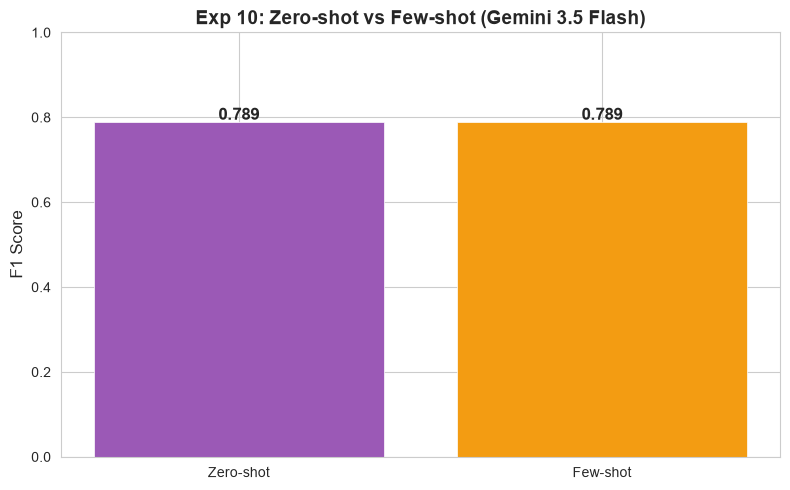

Zero-shot F1: 0.789
Few-shot F1:  0.789
Difference:   +0.000

Conclusion: Few-shot adds no benefit for this task.


In [5]:
modes = list(exp10.keys())
f1_modes = [exp10[m]['f1_mean'] for m in modes]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#9b59b6', '#f39c12']
bars = ax.bar(modes, f1_modes, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, f1_modes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Exp 10: Zero-shot vs Few-shot (Gemini 3.5 Flash)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'parser_zeroshot_fewshot.png', bbox_inches='tight')
plt.show()

print(f'Zero-shot F1: {f1_modes[0]:.3f}')
print(f'Few-shot F1:  {f1_modes[1]:.3f}')
print(f'Difference:   {f1_modes[1] - f1_modes[0]:+.3f}')
print('\nConclusion: Few-shot adds no benefit for this task.')

## 4. Resumo

In [6]:
print('=' * 55)
print('PARSER COMPARISON SUMMARY')
print('=' * 55)
print(f'''
Regex Parser:
  - F1: {exp9["Regex"]["f1_mean"]:.3f}
  - ANLS: {exp9["Regex"]["anls_mean"]:.3f}
  - Latency: {exp9["Regex"]["avg_time_ms"]:.1f}ms
  - Cost: $0 (runs locally)

LLM Parser (Gemini 3.5 Flash):
  - F1: {exp9["LLM (Gemini)"]["f1_mean"]:.3f} (+{(exp9["LLM (Gemini)"]["f1_mean"]-exp9["Regex"]["f1_mean"])/exp9["Regex"]["f1_mean"]*100:.0f}% vs Regex)
  - ANLS: {exp9["LLM (Gemini)"]["anls_mean"]:.3f} (+{(exp9["LLM (Gemini)"]["anls_mean"]-exp9["Regex"]["anls_mean"])/exp9["Regex"]["anls_mean"]*100:.0f}% vs Regex)
  - Latency: {exp9["LLM (Gemini)"]["avg_time_ms"]:.0f}ms
  - Cost: ~$0.01/receipt
  - Zero-shot = Few-shot (no benefit from examples)

Recommendations:
  - Use Regex for high-volume, cost-sensitive applications
  - Use LLM for accuracy-critical applications
  - Few-shot prompting not needed with modern models
''')

PARSER COMPARISON SUMMARY

Regex Parser:
  - F1: 0.554
  - ANLS: 0.517
  - Latency: 4.2ms
  - Cost: $0 (runs locally)

LLM Parser (Gemini 3.5 Flash):
  - F1: 0.681 (+23% vs Regex)
  - ANLS: 0.747 (+45% vs Regex)
  - Latency: 4286ms
  - Cost: ~$0.01/receipt
  - Zero-shot = Few-shot (no benefit from examples)

Recommendations:
  - Use Regex for high-volume, cost-sensitive applications
  - Use LLM for accuracy-critical applications
  - Few-shot prompting not needed with modern models

